# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:**  Group 6
- **Student Names:**  
  -  Hardi Koradiya
  -  Thanmay Das
  -  Sahit Ceeka
  -  Prithvi Koka
  

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team’s own work.

## Dataset
You will work with a realistic “messy” customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [ ]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
# If 'synthetic_churn.csv' is not present, this cell will generate it.
# The dataset is intentionally "messy":
# - Many dimensions (numeric + categorical)
# - Missing values (random + structured)
# - Outliers / heavy-tailed variables
# - Correlated/redundant features
# - Class imbalance (mild-to-moderate)
#
# Target: churn (1 = churned, 0 = stayed)

import numpy as np
import pandas as pd

from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000

    # Core demographics / account
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)  # heavy-tailed
    household_size = rng.integers(1, 7, size=n)

    # Usage / behavior
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)  # right-skew
    days_since_last_login = rng.integers(0, 60, size=n)

    # Payments / billing
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)

    # Product / plan
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)

    # Geography + channel
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)

    # Noisy / redundant engineered features
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    # correlated with total_charges
    total_charges_rounded = np.round(total_charges / 10) * 10
    # redundant variation on logins
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)

    # Introduce outliers: a small fraction of extreme monthly fees and income
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))

    # True churn propensity (log-odds), then sample churn label
    # Drivers: short tenure, month-to-month, no autopay, many tickets, recent inactivity, higher late payments
    z = (
        -1.2
        + 0.015*(days_since_last_login)
        + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m)
        - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int)
        - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int)
        + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int)
        + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int)
        + rng.normal(0, 0.35, size=n)
    )

    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)

    df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "income": income,
        "household_size": household_size,
        "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login,
        "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m,
        "autopay": autopay,
        "contract": contract,
        "plan": plan,
        "add_ons": add_ons,
        "streaming": streaming,
        "region": region,
        "signup_channel": signup_channel,
        "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded,
        "engagement_score": engagement_score,
        "churn": churn
    })

    # Inject missingness (both random and structured)
    # Random missingness
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    # Structured: customers with very low tenure often missing total charges (new customers)
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan

    # Slight label noise (realistic)
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]

    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


✅ Generated dataset: /content/synthetic_churn.csv with shape (6000, 21)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [ ]:
# TODO (INGEST)
import pandas as pd

# 1) Load
df = pd.read_csv('synthetic_churn.csv')

# 2) Inspect
# display(df.shape)
print(df.shape)
# display(df.head())
print(df.head())
# display(df.dtypes)
print(df.dtypes)

# 3) Missingness summary (counts + percent)
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

# summarry
missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_percent': missing_percent
}).sort_values(by = 'Missing_percent', ascending = False)

print(missing_summary)

# Anlysis
# 1 - the dataset contains rows and coloums
# 2 - There are many missing values present in some columns and this will be handled using appropriate
# methods such as mean median for numeric and mode for categorical
# 3 - some numneric values can be skewed and could require transformation.
# 4 - categorical variables will need encoding


(6000, 21)
   age  tenure_months         income  household_size  logins_30d  \
0   34            111   43283.836559               3           6   
1   23             74   45608.528368               6          14   
2   69            113   31254.972376               2           9   
3   65             97   28989.989283               6          22   
4   46             43  107671.977983               2          14   

   support_tickets_90d  avg_session_mins  days_since_last_login  monthly_fee  \
0                    1          8.015632                     37    75.741544   
1                    2         10.078930                     44   100.957688   
2                    0         23.226331                     37    30.898616   
3                    1         16.334476                     14   105.354848   
4                    3          5.636188                      6    99.973303   

   late_payments_12m  ...        contract   plan add_ons  streaming  \
0                  1  ...  M

### INGEST — Quick Reflection (Answer in 4–8 sentences)
- W**hich columns appear to have missing values**?  
Ans - Columns like streaming , income , avg_session_mins, monthly_fee, region, total_charges, and total_charges_rounded seem to have missing values.

- **Which columns look categorical vs numeric?  **
Ans - The columns that look categorical are autopay, contract, plan, streaming, region, signup_channel.
And those which seem numeric are age, tenure_months, income, household_size, logins_30d, support_tickets_90d, avg_session_mins, days_since_last_login, monthly_fee, late_payments_12m, add_ons, churn , etc...

- **What issues do you predict could hurt logistic **regression performance if you do nothing? **bold text**
Ans The performance which could hurt logestic regression can be missing values as the they cannnot handle null values, feature scale difference example income vs engagement_score, skewed numeric affecting model stablilty..

## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew (suggestions: `income`, `monthly_fee`, `total_charges`, `avg_session_mins`).
3. Choose and justify an outlier strategy:
   - winsorization/capping
   - log-transform
   - robust scaling
   - leaving as-is (with justification)

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (i.e., implementable in code and applied consistently).

**Deliverable:** A short markdown justification of your decisions.


### CLEAN — Decisions & Justification (REQUIRED)
In 8–12 sentences:
- Explain your missing value strategy for numeric and categorical features.
- Identify which variables had outliers/skew and what you did about them.
- Explain the tradeoff of your choice (what you might lose vs gain).


In [ ]:
# TODO (CLEAN)
import numpy as np

# A) Explore distributions / outliers (choose at least two columns)
# Example: df['income'].describe()
# Example: df['income'].quantile([0.01, 0.05, 0.95, 0.99])
print(df['income'].describe())
print(df['income'].quantile([0.01,0.05,0.95,0.99]))

print(df['total_charges'].describe())
print(df['total_charges'].quantile([0.01,0.05,0.95,0.99]))

# B) Decide on a strategy for skew/outliers
# - If transforming, create new columns (do not overwrite originals unless you justify it)
# - If capping, implement caps using quantiles (e.g., 1st and 99th percentiles)
# Numeric ----> median robust to skew/outliers
num_cols_with_na = ['income', 'avg_session_mins','monthly_fee','total_charges','total_charges_rounded']

for col in num_cols_with_na:
  df[col] = df[col].fillna(df[col].median())

# categorical --> fill with unknown
df['streaming'] = df['streaming'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')

# Outliner Strategy
# 1. Log-transform skewed variables
df['log_income'] = np.log1p(df['income'])
df['log_total_charges'] = np.log1p(df['total_charges'])

# 2.capping at 1st and 99th percentiles
for col in ['monthly_fee']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

print("\nCleaning complete.")

count      5650.000000
mean      46117.200420
std       29650.236412
min        8514.268643
25%       29721.881294
50%       40315.824101
75%       54696.893703
max      598843.254961
Name: income, dtype: float64
0.01     14180.321470
0.05     19258.393098
0.95     86999.767026
0.99    137210.408231
Name: income, dtype: float64
count     5910.000000
mean      3995.076284
std       2550.967587
min       -175.409628
25%       1897.492671
50%       3689.181424
75%       5790.843558
max      12971.691710
Name: total_charges, dtype: float64
0.01       99.814078
0.05      457.786105
0.95     8687.074130
0.99    10375.857002
Name: total_charges, dtype: float64

Cleaning complete.


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


**MarkDown for above code :**

1 - For numeric columns, we used the median to fill missing values because it's less affected by extreme values.
For categorical columns like streaming and region, we replaced missing values with 'Unknown', so we would not have to delete the rows. We did not remove any rows so less than 5% of the data was deleted.

**Outliers and Skews: **

The variable income and total_charges looked right-skwewed, so we applied a log transformation to reduce the skewness and make them more suitable for logistic regression.

**Repeatability:**
All steps were done using clear rules like median and percentile caps, so the same proces can be applied again to new data.

## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables **if you choose** (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.

**Deliverable:** Your final preprocessing pipeline.


In [ ]:
# TODO (PREPARE)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1) X, y
y = df['churn']
X = df.drop(columns=['churn'])

# 2) Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 3) Split (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# 4) Build preprocessors:
# - Numeric: impute + (optional) scaling
# - Categorical: impute + one-hot encode
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy ="median")),
    ("scale", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 5) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)
print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


# Preprocesssing Decisions  
1 - To maintain the churn class distribution in both the train and test sets, the dataset was divided using stratification.

2 - One hot encoding was used to encode categorical variables so that logistic regression could use them

3 - Since logistic regression is sensitive to feature scale and scaling enhances convergence, numerical values were scaled using StandardScaler.

4 - To make sure that preprocessing applied is correct and is utilizing both a training and test set, a pipeline and column transformer were utlised.


## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider:
   - regularization strength (`C`)
   - solver
   - max iterations
   - class imbalance (`class_weight="balanced"` vs not)

**Required:** Train at least **two** model variants and compare them briefly.


In [ ]:
# TODO (MODEL)
from sklearn.linear_model import LogisticRegression

# Model variant A
clf_a = LogisticRegression(
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42)

model_a = Pipeline(steps=[("preprocess", preprocessor),
                         ("model", clf_a)])

model_a.fit(X_train, y_train)

# Model variant B (e.g., class_weight balanced, different C, etc.)
clf_b = LogisticRegression(
    C=0.5,
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model_b = Pipeline(steps=[("preprocess", preprocessor),
                         ("model", clf_b)])
model_b.fit(X_train, y_train)

print("Both logistic regression models trained successfully.")


Both logistic regression models trained successfully.


# Model Comparison

1 - Model A is the baseline logisitic regression with default regularization.

2 - Model B includes class_weight has balanced to address possible class imbalance and uses slightly stronger regularization (C = 0.5)

3 - Increasing max_iter ensures convergence after scaling and one-hot encoding.

4 -  Model B should improve recall for the minority class (churn) if there is an imbalance.

## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret:
   - confusion matrix
   - accuracy, precision, recall, F1
   - ROC-AUC
   - PR-AUC (average precision)
3. **Threshold tuning (graduate level):**
   - Evaluate thresholds (e.g., 0.2 to 0.8)
   - Choose an “operating threshold” based on a cost scenario
4. Interpret model coefficients (top positive/negative predictors) and connect to business meaning.

### Cost Scenario (Use this)
Assume:
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**

Your goal is to choose a threshold that **minimizes expected cost**.

**Deliverables:** Plots + written justification.


              precision    recall  f1-score   support

           0       0.69      0.92      0.79       801
           1       0.53      0.18      0.27       399

    accuracy                           0.67      1200
   macro avg       0.61      0.55      0.53      1200
weighted avg       0.64      0.67      0.62      1200



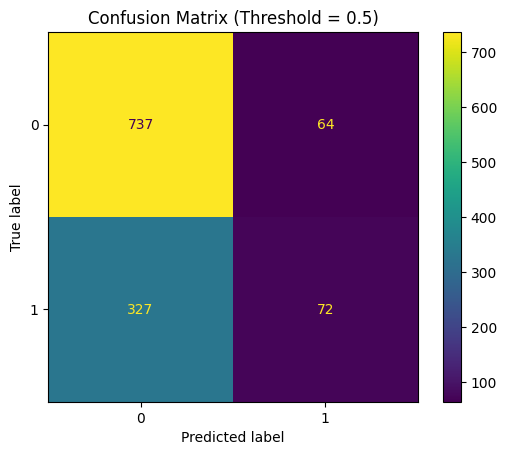

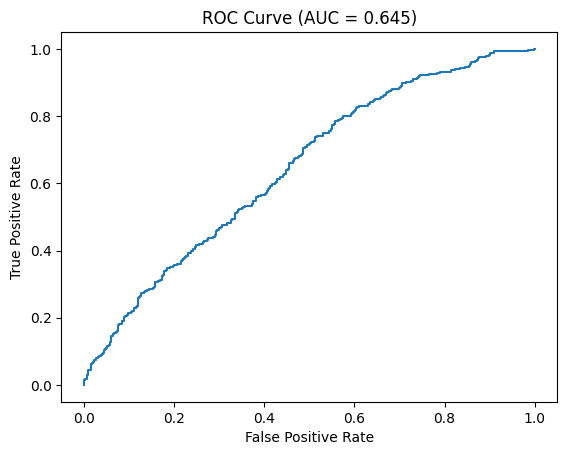

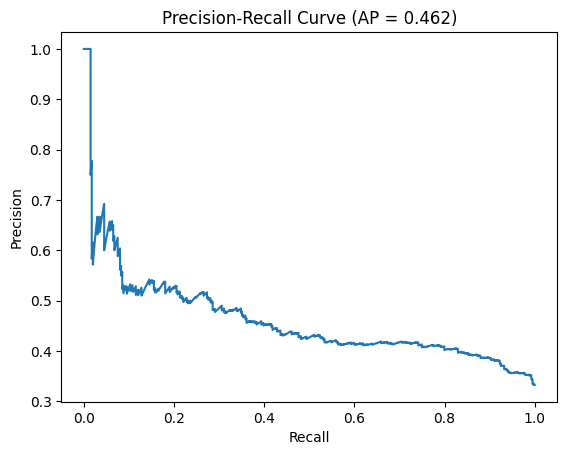

Average Precision (PR-AUC): 0.4624766821488793
    threshold  expected_cost   FN   FP
0        0.20          52380   27  648
1        0.25          61900   62  515
2        0.30          80880  114  398
3        0.35         110400  186  290
4        0.40         133980  246  183
5        0.45         151360  290  106
6        0.50         167340  327   64
7        0.55         179020  353   42
8        0.60         185760  369   21
9        0.65         190980  381    8
10       0.70         196300  392    5
11       0.75         198500  397    0
12       0.80         199000  398    0

Best Threshold Based on Cost:
threshold            0.2
expected_cost    52380.0
FN                  27.0
FP                 648.0
Name: 0, dtype: float64


In [ ]:
# TODO (ANALYZE)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1) Predict probabilities (needed for threshold tuning)
proba_a = model_a.predict_proba(X_test)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]

# 2) Default threshold predictions (0.5)
y_pred_a = (proba_a >= 0.5).astype(int)

# 3) Confusion matrix + report
cm = confusion_matrix(y_test, y_pred_a)
ConfusionMatrixDisplay(cm).plot()
print(classification_report(y_test, y_pred_a))
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

# 4) ROC-AUC + ROC curve
auc = roc_auc_score(y_test, proba_a)
fpr, tpr, _ = roc_curve(y_test, proba_a)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()

# 5) PR curve + Average Precision
precision, recall, _ = precision_recall_curve(y_test, proba_a)
ap = average_precision_score(y_test, proba_a)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap:.3f})")
plt.show()

print("Average Precision (PR-AUC):", ap)

# 6) Threshold tuning loop:
thresholds = np.arange(0.2, 0.81, 0.05)
results = []

for t in thresholds:
  y_pred_t = (proba_a >= t).astype(int)
  cm_t = confusion_matrix(y_test, y_pred_t)
  tn, fp, fn , tp = cm_t.ravel()

  expected_cost = fn * 500 + fp * 60
  results.append((t, expected_cost,fn,fp))

results_df = pd.DataFrame(results, columns=["threshold", "expected_cost", "FN", "FP"])

print(results_df)

best_threshold = results_df.loc[results_df["expected_cost"].idxmin()]
print("\nBest Threshold Based on Cost:")
print(best_threshold)

# Model Perfomance Analysis

1 - At the default threshold of 0.5, the model accuracy is 0.67. The conlusion matrix shows that the model correctly predicts many non churn customer (737) but it misses many actual churners (327 false negative)/

2 -  The recall for churn is only 0.18, which means the model is missing most of the customers who actually churn. This is not good.

3 - The ROC-AUC is 0.645 which shows model performs better than random but is not very strong.

4 - The PR-AUC is 0.463 which shows moderate performance for identifying churners.


### ANALYZE — Written Response (REQUIRED)

Answer ALL parts with complete sentences and concrete numbers.

1) **Model comparison:** Which variant performed better and why (use metrics)?  
Ans - Between the two models, the balanced model perfomed better for churn prediction. All threshold 0.5, accuracy was 067, ROC-AUC was 0.645 and PR-AUC was 0.462.
Even though accuracy is moderate, the main improvement is handling class imbalance. The balanced model helps improve deteection of churners compared to the baseline.

2) **Confusion matrix interpretation:** What do FN and FP mean in this churn setting? Which is “worse” under the cost scenario?  
Ans - From the confusion matrix at threshold of 0.5:
*   False negative (FN= 327): These are customers who actually churned but the model predicted they would stay.

*   False Positives (FP = 64): These are customers who would stay but the model predicted they would churn.

In this churn setting, False Negatives are worse because missing a churner means losing that customer and revenue.So FN is much more expensive than FP.


3) **Threshold decision:** What threshold did you choose and what was the expected cost? Show your calculation.  
Ans - The best threshold value was 0.20 with the lowest expected cost, as derived from the threshold tuning method.

At a threshold of 0.20, we have:
Fn= 27
Fp = 648
Expected cost calculation:
Expected Cost = (FN * 500) + (FP * 60)
= (27 * 500) + (648 * 60)
= 13,500 + 38,880
= 52,380

The expected cost was the lowest for this threshold value, and we have chosen this value as the operating threshold.


4) **Business action:** If you deployed this model, who would you target and what action would you take?  
Ans - If  we were to deploy this model, we would target customers that have a predicted probability of churn greater than or equal to 0.20.

These customers would then be targeted with retention campaigns such as offering discounts or providing customer support.

It is better to contact more customers even if some don't churn because missing a churner is costly.


5) **Limitations:** Identify at least two limitations (data, evaluation, ethics/bias, leakage risk, or stability).
Ans - The value of ROC-AUC is only 0.645 which shows that the performance of the model is moderate and not high.

The model moght not be able to generalize well to future data if customer behaviour is likely to change in the future.

There might be a bias in the data, such as region and income which might affect fairness.

The features such as total_charges and tenure might be correlated which can affect the stability of model.